In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [4]:
# build the datasets
block_size = 3
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
n_emb = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MPL
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_emb), generator=g)

layers = [
    Linear(n_emb * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer, make less confident
    layers[-1].weight *= 0.1
    # all other layers, apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True
        

46497


In [6]:
# optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update values
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break # AFTER_DEBUG take out



      0/ 200000: 3.2962


layer 1 Tanh: mean -0.02, std 0.75, saturated 20.25 %
layer 3 Tanh: mean -0.00, std 0.69, saturated 8.38 %
layer 5 Tanh: mean +0.00, std 0.67, saturated 6.62 %
layer 7 Tanh: mean -0.01, std 0.66, saturated 5.47 %
layer 9 Tanh: mean -0.02, std 0.66, saturated 6.12 %


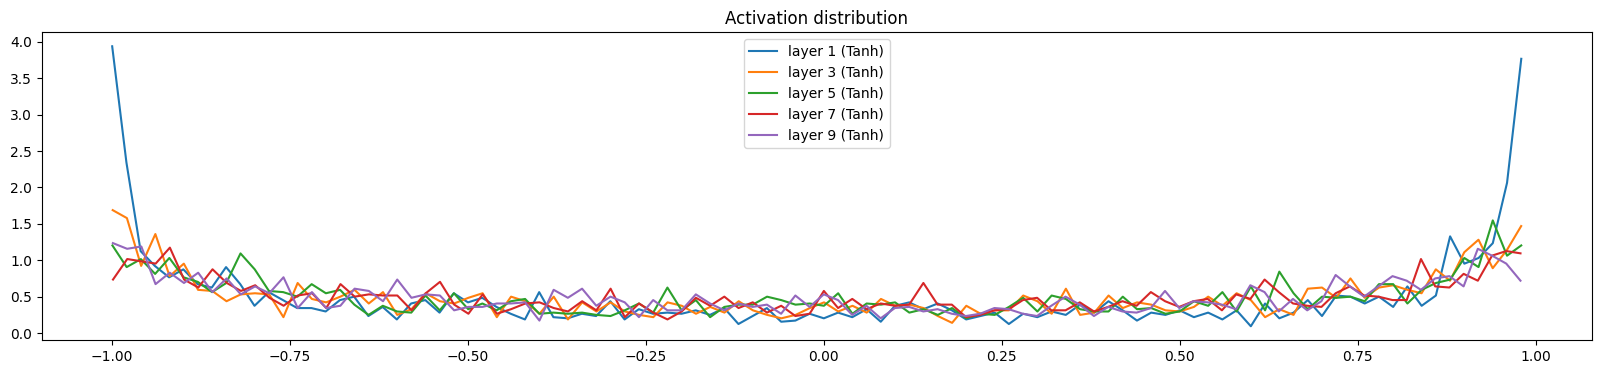

In [ ]:
# visualize histograms, outputs
# we'd like the activations to be equally distributed with tanh, and not highly on the outer rims (-1, 1), since
# that effectively saturates the neurons, recall the derivative of tanh:
# d_tanh = 1 - tanh(out)**2, giving out 0 if the values are high

plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]): # note, exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'layer {i} {layer.__class__.__name__}: mean {t.mean():+.2f}, std {t.std():.2f}, saturated {(t.abs() > 0.97).float().mean()*100:.2f} %')
        hy, hx = torch.histogram(t, density=True) # returns hist, bin_edges
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Activation distribution');


layer 1 (Tanh): mean	0.00001000	std	0.00042056
layer 3 (Tanh): mean	-0.00000343	std	0.00039912
layer 5 (Tanh): mean	0.00000308	std	0.00037430
layer 7 (Tanh): mean	0.00001507	std	0.00032905
layer 9 (Tanh): mean	-0.00001368	std	0.00030540


Text(0.5, 1.0, 'gradient distribution')

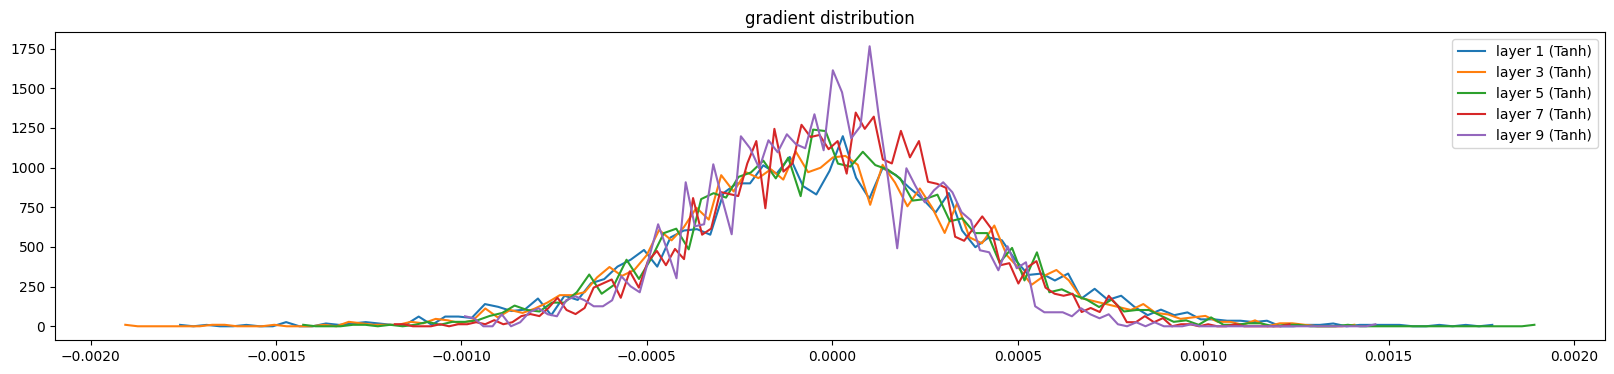

In [8]:
# visualize histograms, gradients

plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'layer {i} ({layer.__class__.__name__}): mean\t{+t.mean():.8f}\tstd\t{t.std():.8f}')
        hy, hx = torch.histogram(t, density=True) # returns hist, bin_edges
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')


weight	(27, 10)	| mean	-0.00003073	| std	0.00136508	| grad:data ratio 0.0013640897814184427
weight	(30, 100)	| mean	-0.00004929	| std	0.00120743	| grad:data ratio 0.003871659515425563
weight	(100, 100)	| mean	0.00001636	| std	0.00109673	| grad:data ratio 0.00660198787227273
weight	(100, 100)	| mean	-0.00001010	| std	0.00098936	| grad:data ratio 0.005893091205507517
weight	(100, 100)	| mean	-0.00001112	| std	0.00086234	| grad:data ratio 0.0051581235602498055
weight	(100, 100)	| mean	-0.00000414	| std	0.00073886	| grad:data ratio 0.004415211267769337
weight	(100, 27)	| mean	-0.00000000	| std	0.02364824	| grad:data ratio 2.328202724456787


Text(0.5, 1.0, 'weights gradient distribution')

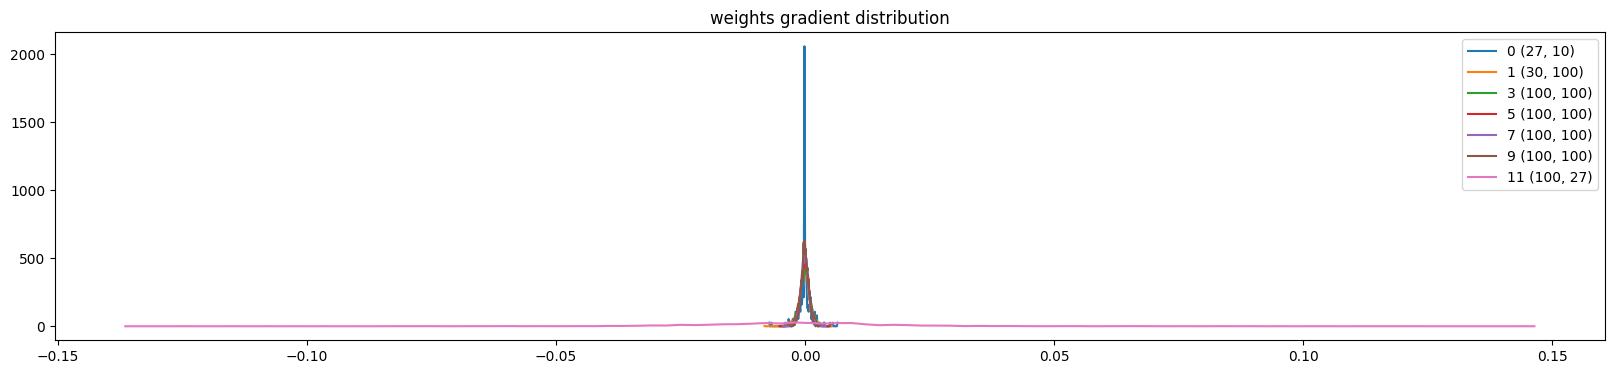

In [9]:
# visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print(f'weight\t{tuple(p.shape)}\t| mean\t{+t.mean():.8f}\t| std\t{t.std():.8f}\t| grad:data ratio {t.std() / p.std()}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')